## Analisis Pola Demand, Metode Pembayaran, dan Karakteristik Penumpang Taxi NYC TLC

**Nama:** Alvin Pranatha  
**Program:** JC BDA  
**Dataset:** NYC TLC Trip Record

Notebook ini disusun supaya alurnya jelas: **business problem → data understanding → data cleaning → analysis → statistical testing → insight → recommendation → dashboard plan**.


# 1. Latar Belakang

New York City memiliki layanan taxi dengan volume perjalanan yang tinggi. Dalam operasional taxi, perusahaan/operator perlu memahami pola perjalanan pelanggan agar dapat menyesuaikan jumlah armada, waktu operasional, dan strategi layanan dengan kebutuhan pasar.

Dataset ini berisi catatan perjalanan Taxi, termasuk waktu pickup/dropoff, jarak perjalanan, jumlah penumpang, metode pembayaran, fare, tip, dan total amount. Pada analisis ini, fokus utama diarahkan pada pola demand berdasarkan jam pickup, metode pembayaran yang digunakan pelanggan, karakteristik jumlah penumpang, serta ringkasan performa perjalanan melalui KPI utama.

## Stakeholder

Stakeholder utama dalam analisis ini adalah:
- **Taxi fleet operator / operations manager**, yang ingin mengatur ketersediaan armada pada jam dengan demand tinggi.
- **Business strategy team**, yang ingin memahami perilaku pelanggan dari sisi metode pembayaran dan jumlah penumpang.
- **Management team**, yang membutuhkan ringkasan performa operasional melalui KPI seperti total trip, average fare, average fare per mile, dan average tip.


# 2. Pernyataan Masalah

Operator taxi perlu memahami pola perjalanan pelanggan agar dapat mengoptimalkan strategi operasional, terutama dalam penyesuaian armada pada jam sibuk dan pemahaman perilaku pembayaran pelanggan. Namun, tanpa analisis data perjalanan, perusahaan sulit mengetahui kapan permintaan perjalanan paling tinggi, metode pembayaran apa yang paling sering digunakan, serta kelompok penumpang seperti apa yang mendominasi perjalanan.

Beberapa masalah yang ingin dijawab dalam analisis ini adalah:

1. Kapan waktu dengan jumlah perjalanan taxi paling tinggi?
2. Metode pembayaran apa yang paling sering digunakan oleh pelanggan?
3. Kelompok jumlah penumpang seperti apa yang paling mendominasi perjalanan?
4. Bagaimana gambaran umum performa perjalanan berdasarkan total trip, average fare, average fare per mile, dan average tip?

## Tujuan Analisis

Analisis ini bertujuan untuk mengidentifikasi pola perjalanan taxi berdasarkan waktu, metode pembayaran, dan jumlah penumpang. Hasil analisis ini dapat digunakan sebagai dasar rekomendasi operasional, khususnya untuk memahami jam dengan permintaan tinggi, preferensi pembayaran pelanggan, serta karakteristik perjalanan yang paling umum terjadi.

## Research Questions

1. Bagaimana pola jumlah perjalanan berdasarkan jam pickup?
2. Pada jam berapa demand perjalanan taxi paling tinggi?
3. Metode pembayaran apa yang paling banyak digunakan oleh pelanggan?
4. Kelompok penumpang apa yang paling dominan dalam perjalanan taxi?
5. Bagaimana performa umum perjalanan berdasarkan total trip, average fare, average fare per mile, dan average tip?


# 3. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 4. Load Data

In [2]:
from pathlib import Path

# Opsi utama: file berada di folder yang sama dengan notebook
file_path = Path('NYC TLC Trip Record.csv')

# Opsi cadangan: lokasi file di laptop lokal
if not file_path.exists():
    file_path = Path('C:/Users/Alvin Pranatha/Desktop/capstone 3/NYC TLC Trip Record.csv')

df_raw = pd.read_csv(file_path, low_memory=False)
df = df_raw.copy()

print(f'File yang digunakan: {file_path}')
print(f'Jumlah baris: {df.shape[0]:,}')
print(f'Jumlah kolom: {df.shape[1]:,}')
display(df.head())


File yang digunakan: C:\Users\Alvin Pranatha\Desktop\capstone 3\NYC TLC Trip Record.csv
Jumlah baris: 68,211
Jumlah kolom: 20


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.00,166,143,1.00,2.58,14.90,1.00,0.50,4.03,0.00,NaN,1.00,24.18,1.00,1.00,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.00,24,43,1.00,1.81,10.70,1.00,0.50,2.64,0.00,NaN,1.00,15.84,1.00,1.00,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.00,223,179,1.00,0.00,7.20,1.00,0.50,1.94,0.00,NaN,1.00,11.64,1.00,1.00,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.00,41,238,1.00,1.30,6.50,0.50,1.50,1.70,0.00,NaN,1.00,10.20,1.00,1.00,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.00,41,74,1.00,1.10,6.00,0.50,1.50,0.00,0.00,NaN,1.00,8.00,1.00,1.00,0.00


# 5. Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               68211 non-null  int64  
 1   lpep_pickup_datetime   68211 non-null  object 
 2   lpep_dropoff_datetime  68211 non-null  object 
 3   store_and_fwd_flag     63887 non-null  object 
 4   RatecodeID             63887 non-null  float64
 5   PULocationID           68211 non-null  int64  
 6   DOLocationID           68211 non-null  int64  
 7   passenger_count        63887 non-null  float64
 8   trip_distance          68211 non-null  float64
 9   fare_amount            68211 non-null  float64
 10  extra                  68211 non-null  float64
 11  mta_tax                68211 non-null  float64
 12  tip_amount             68211 non-null  float64
 13  tolls_amount           68211 non-null  float64
 14  ehail_fee              0 non-null      float64
 15  im

In [4]:
display(df.describe())
display(df.describe(include='object'))

,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,"68,211.00","63,887.00","68,211.00","68,211.00","63,887.00","68,211.00","68,211.00","68,211.00","68,211.00","68,211.00","68,211.00",0.00,"68,211.00","68,211.00","63,887.00","63,877.00","63,887.00"
mean,1.86,1.12,98.55,138.43,1.32,8.11,16.60,0.83,0.59,2.14,0.17,NaN,0.95,21.79,1.37,1.02,0.73
std,0.34,1.37,61.24,76.76,0.98,585.11,13.47,1.27,0.39,3.05,1.10,NaN,0.20,15.46,0.51,0.15,1.21
min,1.00,1.00,1.00,1.00,0.00,0.00,-70.00,-2.50,-0.50,-10.50,0.00,NaN,-1.00,-71.50,1.00,1.00,-2.75
25%,2.00,1.00,74.00,74.00,1.00,1.11,9.30,0.00,0.50,0.00,0.00,NaN,1.00,12.90,1.00,1.00,0.00
50%,2.00,1.00,75.00,138.00,1.00,1.85,13.50,0.00,0.50,1.60,0.00,NaN,1.00,17.90,1.00,1.00,0.00
75%,2.00,1.00,129.00,219.00,1.00,3.21,19.80,1.00,0.50,3.33,0.00,NaN,1.00,26.15,2.00,1.00,2.75
max,2.00,99.00,265.00,265.00,9.00,"120,098.84",490.00,12.50,2.75,222.22,36.05,NaN,1.00,491.00,5.00,2.00,2.75


,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag
count,68211,68211,63887
unique,66575,66519,2
top,2023-01-09 09:08:00,2023-01-09 00:00:00,N
freq,4,6,63579


In [5]:
def missing_table(data):
    missing = data.isna().sum().reset_index()
    missing.columns = ['column', 'missing_count']
    missing['missing_pct'] = (missing['missing_count'] / len(data) * 100).round(2)
    return missing.sort_values('missing_pct', ascending=False)

missing_table(df)

,column,missing_count,missing_pct
14,ehail_fee,68211,100.00
18,trip_type,4334,6.35
19,congestion_surcharge,4324,6.34
3,store_and_fwd_flag,4324,6.34
4,RatecodeID,4324,6.34
17,payment_type,4324,6.34
7,passenger_count,4324,6.34
12,tip_amount,0,0.00
16,total_amount,0,0.00
15,improvement_surcharge,0,0.00


In [6]:
print(f'Jumlah data duplikat: {df.duplicated().sum():,}')

Jumlah data duplikat: 0


In [7]:
# Melihat jumlah unique value untuk tiap kolom
unique_summary = pd.DataFrame({
    'column': df.columns,
    'n_unique': [df[col].nunique(dropna=False) for col in df.columns],
    'sample_values': [df[col].dropna().unique()[:5] for col in df.columns]
})
unique_summary

,column,n_unique,sample_values
0,VendorID,2,"[2, 1]"
1,lpep_pickup_datetime,66575,"[2023-01-01 00:26:10, 2023-01-01 00:51:03, 202..."
2,lpep_dropoff_datetime,66519,"[2023-01-01 00:37:11, 2023-01-01 00:57:49, 202..."
3,store_and_fwd_flag,3,"[N, Y]"
4,RatecodeID,7,"[1.0, 5.0, 4.0, 3.0, 2.0]"
5,PULocationID,226,"[166, 24, 223, 41, 181]"
6,DOLocationID,249,"[143, 43, 179, 238, 74]"
7,passenger_count,11,"[1.0, 2.0, 4.0, 3.0, 6.0]"
8,trip_distance,1870,"[2.58, 1.81, 0.0, 1.3, 1.1]"
9,fare_amount,2553,"[14.9, 10.7, 7.2, 6.5, 6.0]"


# 6. Data Cleaning
Prinsip cleaning yang dipakai:
1. **Tidak langsung menghapus data tanpa alasan.**
2. **Anomali numerik yang tidak logis** seperti jarak 0, durasi 0, dan amount negatif akan dikeluarkan dari dataset analisis utama.
3. **Missing value kategorikal** tidak selalu dihapus. Jika datanya masih berguna untuk analisis demand/revenue, nilainya akan diberi label `Unknown`.
4. **Outlier** tidak langsung dihapus memakai IQR karena data taxi secara natural skewed. Untuk analisis utama, outlier ekstrem akan dibatasi menggunakan percentile agar insight tidak terlalu dipengaruhi nilai ekstrem.

In [8]:
cleaning_log = []

def log_step(step, before_rows, after_rows, reason):
    cleaning_log.append({
        'step': step,
        'rows_before': before_rows,
        'rows_after': after_rows,
        'rows_removed': before_rows - after_rows,
        'reason': reason
    })

## 6.1 Data Formatting: Ubah Kolom Tanggal ke Datetime

In [9]:
# Simpan jumlah baris sebelum proses
before = len(df)

# Convert datetime columns
for col in ['lpep_pickup_datetime', 'lpep_dropoff_datetime']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

after = len(df)
log_step(
    step='Convert pickup/dropoff datetime',
    before_rows=before,
    after_rows=after,
    reason='Kolom waktu perlu bertipe datetime untuk analisis waktu dan perhitungan durasi.'
)

print(df[['lpep_pickup_datetime', 'lpep_dropoff_datetime']].dtypes)
print('Pickup min:', df['lpep_pickup_datetime'].min())
print('Pickup max:', df['lpep_pickup_datetime'].max())
print('Dropoff min:', df['lpep_dropoff_datetime'].min())
print('Dropoff max:', df['lpep_dropoff_datetime'].max())

lpep_pickup_datetime     datetime64[ns]
lpep_dropoff_datetime    datetime64[ns]
dtype: object
Pickup min: 2009-01-01 20:21:27
Pickup max: 2023-02-01 03:10:05
Dropoff min: 2009-01-02 11:07:31
Dropoff max: 2023-02-01 17:27:05


## 6.2 Drop Kolom yang 100% Missing

In [10]:
def missing_table(data):
    missing = data.isna().sum().reset_index()
    missing.columns = ['column', 'missing_count']
    missing['missing_pct'] = (missing['missing_count'] / len(data) * 100).round(2)
    return missing.sort_values('missing_pct', ascending=False)

missing_table(df)

,column,missing_count,missing_pct
14,ehail_fee,68211,100.00
18,trip_type,4334,6.35
19,congestion_surcharge,4324,6.34
3,store_and_fwd_flag,4324,6.34
4,RatecodeID,4324,6.34
17,payment_type,4324,6.34
7,passenger_count,4324,6.34
12,tip_amount,0,0.00
16,total_amount,0,0.00
15,improvement_surcharge,0,0.00


In [11]:
before = len(df)

# Drop column if 100% missing
cols_100_missing = missing_table(df).query('missing_pct == 100')['column'].tolist()
print('Kolom 100% missing:', cols_100_missing)

df = df.drop(columns=cols_100_missing)

after = len(df)
log_step(
    step='Drop 100% missing columns',
    before_rows=before,
    after_rows=after,
    reason=f'Kolom {cols_100_missing} dihapus karena seluruh nilainya kosong dan tidak informatif untuk analisis.'
)

df.head()

Kolom 100% missing: ['ehail_fee']


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.00,166,143,1.00,2.58,14.90,1.00,0.50,4.03,0.00,1.00,24.18,1.00,1.00,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.00,24,43,1.00,1.81,10.70,1.00,0.50,2.64,0.00,1.00,15.84,1.00,1.00,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.00,223,179,1.00,0.00,7.20,1.00,0.50,1.94,0.00,1.00,11.64,1.00,1.00,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.00,41,238,1.00,1.30,6.50,0.50,1.50,1.70,0.00,1.00,10.20,1.00,1.00,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.00,41,74,1.00,1.10,6.00,0.50,1.50,0.00,0.00,1.00,8.00,1.00,1.00,0.00


## 6.3 Filter Periode Analisis

In [12]:
# Cek jumlah record di luar Januari 2023 berdasarkan pickup datetime
period_mask = (df['lpep_pickup_datetime'] >= '2023-01-01') & (df['lpep_pickup_datetime'] < '2023-02-01')

display(df.loc[~period_mask, ['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'trip_distance', 'total_amount']])
print(f'Jumlah record di luar Jan 2023: {(~period_mask).sum():,}')

,lpep_pickup_datetime,lpep_dropoff_datetime,trip_distance,total_amount
298,2022-12-09 14:10:49,2022-12-09 14:22:26,5.37,16.80
318,2022-12-09 14:55:42,2022-12-09 15:33:06,5.48,35.60
17874,2009-01-01 20:21:27,2009-01-02 11:07:31,7.72,43.20
25100,2023-02-01 03:10:05,2023-02-01 03:40:35,4.58,33.96


Jumlah record di luar Jan 2023: 4


In [13]:
before = len(df)

df = df[period_mask].copy()

after = len(df)
log_step(
    step='Filter pickup period to January 2023',
    before_rows=before,
    after_rows=after,
    reason='Analisis difokuskan pada Januari 2023, sehingga record di luar bulan tersebut dikeluarkan.'
)

print(f'Rows after period filter: {len(df):,}')

Rows after period filter: 68,207


## 6.4 Buat Kolom Durasi Perjalanan

In [14]:
df['trip_duration_minutes'] = (
    df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']
).dt.total_seconds() / 60

df[['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'trip_duration_minutes']].head()

,lpep_pickup_datetime,lpep_dropoff_datetime,trip_duration_minutes
0,2023-01-01 00:26:10,2023-01-01 00:37:11,11.02
1,2023-01-01 00:51:03,2023-01-01 00:57:49,6.77
2,2023-01-01 00:35:12,2023-01-01 00:41:32,6.33
3,2023-01-01 00:13:14,2023-01-01 00:19:03,5.82
4,2023-01-01 00:33:04,2023-01-01 00:39:02,5.97


In [15]:
df['trip_duration_minutes'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count   68,207.00
mean        18.08
std         74.85
min          0.00
1%           0.08
5%           3.00
25%          7.22
50%         11.40
75%         17.48
95%         33.27
99%         58.10
max      1,439.88
Name: trip_duration_minutes, dtype: float64

## 6.5 Hapus Trip yang Tidak Valid secara Bisnis

In [16]:
# Cek anomali sebelum filtering
anomaly_check = pd.DataFrame({
    'anomaly': [
        'duration <= 0',
        'duration < 1 minute',
        'duration > 180 minutes',
        'trip_distance <= 0',
        'fare_amount <= 0',
        'total_amount <= 0',
        'tip_amount < 0',
        'extra < 0',
        'mta_tax < 0',
        'improvement_surcharge < 0',
        'congestion_surcharge < 0'
    ],
    'count': [
        (df['trip_duration_minutes'] <= 0).sum(),
        (df['trip_duration_minutes'] < 1).sum(),
        (df['trip_duration_minutes'] > 180).sum(),
        (df['trip_distance'] <= 0).sum(),
        (df['fare_amount'] <= 0).sum(),
        (df['total_amount'] <= 0).sum(),
        (df['tip_amount'] < 0).sum(),
        (df['extra'] < 0).sum(),
        (df['mta_tax'] < 0).sum(),
        (df['improvement_surcharge'] < 0).sum(),
        (df['congestion_surcharge'].fillna(0) < 0).sum()
    ]
})

anomaly_check

,anomaly,count
0,duration <= 0,61
1,duration < 1 minute,1645
2,duration > 180 minutes,263
3,trip_distance <= 0,3350
4,fare_amount <= 0,259
5,total_amount <= 0,248
6,tip_amount < 0,9
7,extra < 0,80
8,mta_tax < 0,165
9,improvement_surcharge < 0,174


In [17]:
before = len(df)

valid_trip_mask = (
    df['trip_duration_minutes'].between(1, 180) &
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0) &
    (df['tip_amount'] >= 0) &
    (df['extra'] >= 0) &
    (df['mta_tax'] >= 0) &
    (df['improvement_surcharge'] >= 0) &
    (df['congestion_surcharge'].fillna(0) >= 0)
)

df = df[valid_trip_mask].copy()

after = len(df)
log_step(
    step='Filter invalid trip records',
    before_rows=before,
    after_rows=after,
    reason='Menghapus trip dengan durasi, jarak, atau amount yang tidak logis untuk perjalanan normal.'
)

print(f'Rows after valid trip filter: {len(df):,}')

Rows after valid trip filter: 63,977


## 6.6 Handling Missing Value Kategorikal

In [18]:
missing_table(df)

,column,missing_count,missing_pct
17,trip_type,4172,6.52
18,congestion_surcharge,4166,6.51
3,store_and_fwd_flag,4166,6.51
4,RatecodeID,4166,6.51
16,payment_type,4166,6.51
7,passenger_count,4166,6.51
0,VendorID,0,0.00
12,tip_amount,0,0.00
15,total_amount,0,0.00
14,improvement_surcharge,0,0.00


In [19]:
# Mapping berdasarkan data dictionary TLC
vendor_map = {
    1: 'Creative Mobile Technologies',
    2: 'Curb Mobility',
    6: 'Myle Technologies'
}

ratecode_map = {
    1: 'Standard rate',
    2: 'JFK',
    3: 'Newark',
    4: 'Nassau/Westchester',
    5: 'Negotiated fare',
    6: 'Group ride',
    99: 'Unknown'
}

payment_map = {
    0: 'Flex Fare',
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}

trip_type_map = {
    1: 'Street-hail',
    2: 'Dispatch'
}

# Buat kolom label agar kolom original tetap aman
for col in ['VendorID', 'RatecodeID', 'payment_type', 'trip_type']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['vendor_label'] = df['VendorID'].map(vendor_map).fillna('Unknown')
df['ratecode_label'] = df['RatecodeID'].map(ratecode_map).fillna('Unknown')
df['payment_label'] = df['payment_type'].map(payment_map).fillna('Unknown')
df['trip_type_label'] = df['trip_type'].map(trip_type_map).fillna('Unknown')
df['store_and_fwd_label'] = df['store_and_fwd_flag'].fillna('Unknown')

# Passenger count dibuat group agar missing dan 0 tidak dipaksakan jadi angka tertentu
def passenger_group(x):
    if pd.isna(x) or x == 0:
        return 'Unknown/0'
    elif x == 1:
        return '1 passenger'
    elif x == 2:
        return '2 passengers'
    else:
        return '3+ passengers'

df['passenger_group'] = df['passenger_count'].apply(passenger_group)

# Congestion surcharge missing diberi indikator, bukan langsung dihapus
df['congestion_surcharge_status'] = np.where(
    df['congestion_surcharge'].isna(),
    'Unknown',
    np.where(df['congestion_surcharge'] > 0, 'Charged', 'Not charged')
)

df[['payment_type', 'payment_label', 'RatecodeID', 'ratecode_label', 'passenger_count', 'passenger_group']].head()

,payment_type,payment_label,RatecodeID,ratecode_label,passenger_count,passenger_group
0,1.00,Credit card,1.00,Standard rate,1.00,1 passenger
1,1.00,Credit card,1.00,Standard rate,1.00,1 passenger
3,1.00,Credit card,1.00,Standard rate,1.00,1 passenger
4,1.00,Credit card,1.00,Standard rate,1.00,1 passenger
5,2.00,Cash,1.00,Standard rate,1.00,1 passenger


## 6.7 Deteksi dan Treatment Outlier

In [20]:
outlier_cols = ['trip_distance', 'trip_duration_minutes', 'total_amount', 'fare_amount', 'tip_amount']

df[outlier_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99, 0.995, 0.999])

,trip_distance,trip_duration_minutes,total_amount,fare_amount,tip_amount
count,"63,977.00","63,977.00","63,977.00","63,977.00","63,977.00"
mean,8.63,13.81,21.77,16.45,2.21
std,604.15,9.74,14.17,11.96,3.00
min,0.01,1.00,1.01,0.01,0.00
25%,1.24,7.48,12.96,9.30,0.00
50%,1.95,11.48,17.94,13.28,1.86
75%,3.34,17.28,26.05,19.71,3.41
95%,7.92,31.45,47.52,37.30,7.00
99%,14.71,49.00,74.71,63.20,11.62
99.5%,17.93,57.91,90.06,70.98,14.78


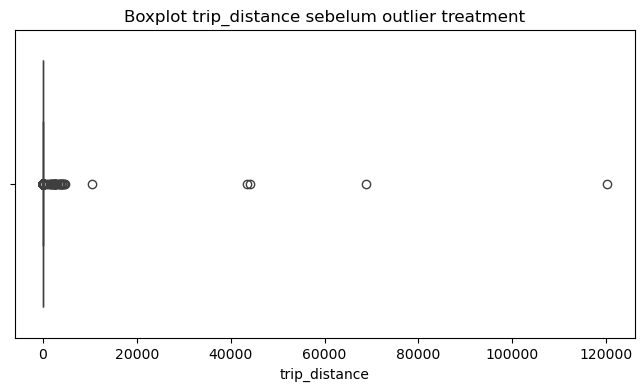

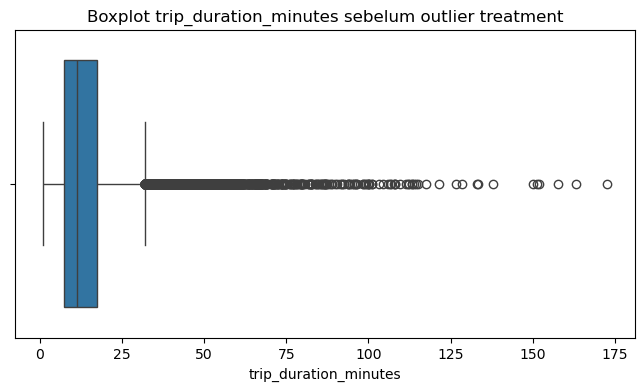

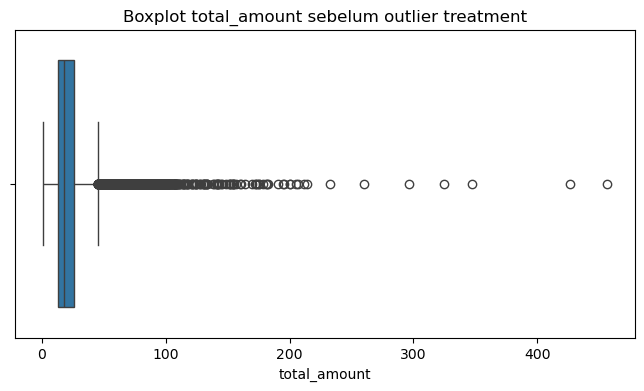

In [21]:
# Visualisasi distribusi sebelum outlier treatment
for col in ['trip_distance', 'trip_duration_minutes', 'total_amount']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col} sebelum outlier treatment')
    plt.show()

In [22]:
# Hitung IQR hanya untuk diagnosis, bukan otomatis untuk drop
outlier_diagnosis = []

for col in ['trip_distance', 'trip_duration_minutes', 'total_amount']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    p99 = df[col].quantile(0.99)
    
    outlier_diagnosis.append({
        'column': col,
        'q1': q1,
        'q3': q3,
        'iqr_upper_bound': upper,
        'p99': p99,
        'count_above_iqr': (df[col] > upper).sum(),
        'count_above_p99': (df[col] > p99).sum()
    })

pd.DataFrame(outlier_diagnosis)

,column,q1,q3,iqr_upper_bound,p99,count_above_iqr,count_above_p99
0,trip_distance,1.24,3.34,6.49,14.71,5492,640
1,trip_duration_minutes,7.48,17.28,31.98,49.00,3066,627
2,total_amount,12.96,26.05,45.69,74.71,3647,640


In [23]:
before = len(df)

p99_distance = df['trip_distance'].quantile(0.99)
p99_duration = df['trip_duration_minutes'].quantile(0.99)
p99_total = df['total_amount'].quantile(0.99)

main_analysis_mask = (
    (df['trip_distance'] <= p99_distance) &
    (df['trip_duration_minutes'] <= p99_duration) &
    (df['total_amount'] <= p99_total)
)

df_outlier = df[~main_analysis_mask].copy()
df_clean = df[main_analysis_mask].copy()

after = len(df_clean)
log_step(
    step='Separate extreme outliers using p99 threshold',
    before_rows=before,
    after_rows=after,
    reason='Outlier ekstrem dipisahkan agar analisis utama tidak terlalu dipengaruhi nilai yang sangat tinggi.'
)

print(f'Data utama setelah outlier treatment: {len(df_clean):,}')
print(f'Data outlier yang dipisahkan: {len(df_outlier):,}')
print('Batas p99 trip_distance:', round(p99_distance, 2))
print('Batas p99 duration:', round(p99_duration, 2))
print('Batas p99 total_amount:', round(p99_total, 2))

Data utama setelah outlier treatment: 62,821
Data outlier yang dipisahkan: 1,156
Batas p99 trip_distance: 14.71
Batas p99 duration: 49.0
Batas p99 total_amount: 74.71


## 6.8 Feature Engineering

In [24]:
# Feature waktu
df_clean['pickup_date'] = df_clean['lpep_pickup_datetime'].dt.date
df_clean['pickup_day'] = df_clean['lpep_pickup_datetime'].dt.day
df_clean['pickup_hour'] = df_clean['lpep_pickup_datetime'].dt.hour
df_clean['pickup_weekday'] = df_clean['lpep_pickup_datetime'].dt.day_name()
df_clean['is_weekend'] = df_clean['pickup_weekday'].isin(['Saturday', 'Sunday'])

# Segmentasi waktu
def time_period(hour):
    if 5 <= hour <= 10:
        return 'Morning'
    elif 11 <= hour <= 15:
        return 'Afternoon'
    elif 16 <= hour <= 20:
        return 'Evening'
    else:
        return 'Night'

df_clean['time_period'] = df_clean['pickup_hour'].apply(time_period)

# Feature revenue/tip
# total_without_tip membantu membandingkan charge sebelum tip tercatat
df_clean['total_without_tip'] = df_clean['total_amount'] - df_clean['tip_amount']
df_clean['tip_rate'] = np.where(
    df_clean['total_without_tip'] > 0,
    df_clean['tip_amount'] / df_clean['total_without_tip'],
    np.nan
)

# Fare efficiency
df_clean['fare_per_mile'] = np.where(
    df_clean['trip_distance'] > 0,
    df_clean['fare_amount'] / df_clean['trip_distance'],
    np.nan
)

# Route feature
df_clean['route'] = df_clean['PULocationID'].astype(str) + ' → ' + df_clean['DOLocationID'].astype(str)

# Revenue segment
df_clean['revenue_segment'] = pd.qcut(
    df_clean['total_amount'],
    q=[0, 0.5, 0.75, 0.9, 1],
    labels=['Low', 'Medium', 'High', 'Very High']
)

df_clean.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,trip_duration_minutes,vendor_label,ratecode_label,payment_label,trip_type_label,store_and_fwd_label,passenger_group,congestion_surcharge_status,pickup_date,pickup_day,pickup_hour,pickup_weekday,is_weekend,time_period,total_without_tip,tip_rate,fare_per_mile,route,revenue_segment
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.00,166,143,1.00,2.58,14.90,1.00,0.50,4.03,0.00,1.00,24.18,1.00,1.00,2.75,11.02,Curb Mobility,Standard rate,Credit card,Street-hail,N,1 passenger,Charged,2023-01-01,1,0,Sunday,True,Night,20.15,0.20,5.78,166 → 143,Medium
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.00,24,43,1.00,1.81,10.70,1.00,0.50,2.64,0.00,1.00,15.84,1.00,1.00,0.00,6.77,Curb Mobility,Standard rate,Credit card,Street-hail,N,1 passenger,Not charged,2023-01-01,1,0,Sunday,True,Night,13.20,0.20,5.91,24 → 43,Low
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.00,41,238,1.00,1.30,6.50,0.50,1.50,1.70,0.00,1.00,10.20,1.00,1.00,0.00,5.82,Creative Mobile Technologies,Standard rate,Credit card,Street-hail,N,1 passenger,Not charged,2023-01-01,1,0,Sunday,True,Night,8.50,0.20,5.00,41 → 238,Low
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.00,41,74,1.00,1.10,6.00,0.50,1.50,0.00,0.00,1.00,8.00,1.00,1.00,0.00,5.97,Creative Mobile Technologies,Standard rate,Credit card,Street-hail,N,1 passenger,Not charged,2023-01-01,1,0,Sunday,True,Night,8.00,0.00,5.45,41 → 74,Low
5,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1.00,41,262,1.00,2.78,17.70,1.00,0.50,0.00,0.00,1.00,22.95,2.00,1.00,2.75,17.55,Curb Mobility,Standard rate,Cash,Street-hail,N,1 passenger,Charged,2023-01-01,1,0,Sunday,True,Night,22.95,0.00,6.37,41 → 262,Medium


## 6.9 Final Check dan Cleaning Summary

In [25]:
print(f'Raw data rows: {len(df_raw):,}')
print(f'Clean data rows for analysis: {len(df_clean):,}')
print(f'Rows removed/separated from main analysis: {len(df_raw) - len(df_clean):,}')
print(f'Jumlah kolom final: {df_clean.shape[1]:,}')

missing_table(df_clean)

Raw data rows: 68,211
Clean data rows for analysis: 62,821
Rows removed/separated from main analysis: 5,390
Jumlah kolom final: 38


,column,missing_count,missing_pct
17,trip_type,3956,6.30
3,store_and_fwd_flag,3952,6.29
4,RatecodeID,3952,6.29
18,congestion_surcharge,3952,6.29
7,passenger_count,3952,6.29
16,payment_type,3952,6.29
0,VendorID,0,0.00
28,pickup_day,0,0.00
24,store_and_fwd_label,0,0.00
25,passenger_group,0,0.00


In [26]:
cleaning_summary = pd.DataFrame(cleaning_log)
cleaning_summary

,step,rows_before,rows_after,rows_removed,reason
0,Convert pickup/dropoff datetime,68211,68211,0,Kolom waktu perlu bertipe datetime untuk anali...
1,Drop 100% missing columns,68211,68211,0,Kolom ['ehail_fee'] dihapus karena seluruh nil...
2,Filter pickup period to January 2023,68211,68207,4,"Analisis difokuskan pada Januari 2023, sehingg..."
3,Filter invalid trip records,68207,63977,4230,"Menghapus trip dengan durasi, jarak, atau amou..."
4,Separate extreme outliers using p99 threshold,63977,62821,1156,Outlier ekstrem dipisahkan agar analisis utama...


In [27]:
# Export cleaned data untuk Tableau / Looker Studio
output_path = 'nyc_tlc_cleaned_for_dashboard.csv'
df_clean.to_csv(output_path, index=False)
print(f'Cleaned data exported to: {output_path}')

Cleaned data exported to: nyc_tlc_cleaned_for_dashboard.csv


# 7. Exploratory Data Analysis
1. Ringkasan KPI perjalanan
2. Pola demand berdasarkan jam pickup
3. Distribusi metode pembayaran
4. Distribusi kelompok penumpang


## 7.1 KPI Summary

KPI berikut digunakan sebagai ringkasan performa utama pada dashboard:
- **Total Trip**: jumlah perjalanan valid setelah proses cleaning
- **Average Fare**: rata-rata fare amount
- **Average Fare per Mile**: rata-rata fare per mile
- **Average Tip**: rata-rata tip yang tercatat


In [28]:
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Trip',
        'Average Fare',
        'Average Fare per Mile',
        'Average Tip'
    ],
    'Value': [
        len(df_clean),
        df_clean['fare_amount'].mean(),
        df_clean['fare_per_mile'].mean(),
        df_clean['tip_amount'].mean()
    ]
})

kpi_summary['Value'] = kpi_summary['Value'].round(2)
kpi_summary


,Metric,Value
0,Total Trip,"62,821.00"
1,Average Fare,15.53
2,Average Fare per Mile,8.04
3,Average Tip,2.11


KPI summary membantu melihat performa umum dataset secara cepat. Pada dashboard final, KPI ini ditampilkan sebagai scorecard agar stakeholder bisa langsung memahami skala data dan rata-rata nilai perjalanan.


## 7.2 Pola Demand Berdasarkan Jam Pickup


In [29]:
hourly_demand = df_clean.groupby('pickup_hour').agg(
    total_trips=('pickup_hour', 'count'),
    avg_fare=('fare_amount', 'mean'),
    avg_tip=('tip_amount', 'mean')
).reset_index()

hourly_demand.sort_values('pickup_hour')


,pickup_hour,total_trips,avg_fare,avg_tip
0,0,1024,16.02,1.95
1,1,804,16.33,2.22
2,2,569,18.24,2.15
3,3,479,18.27,1.86
4,4,369,19.28,2.35
5,5,344,18.52,2.28
6,6,894,15.83,2.15
7,7,2436,15.24,2.09
8,8,2968,16.08,2.17
9,9,3244,15.95,2.10


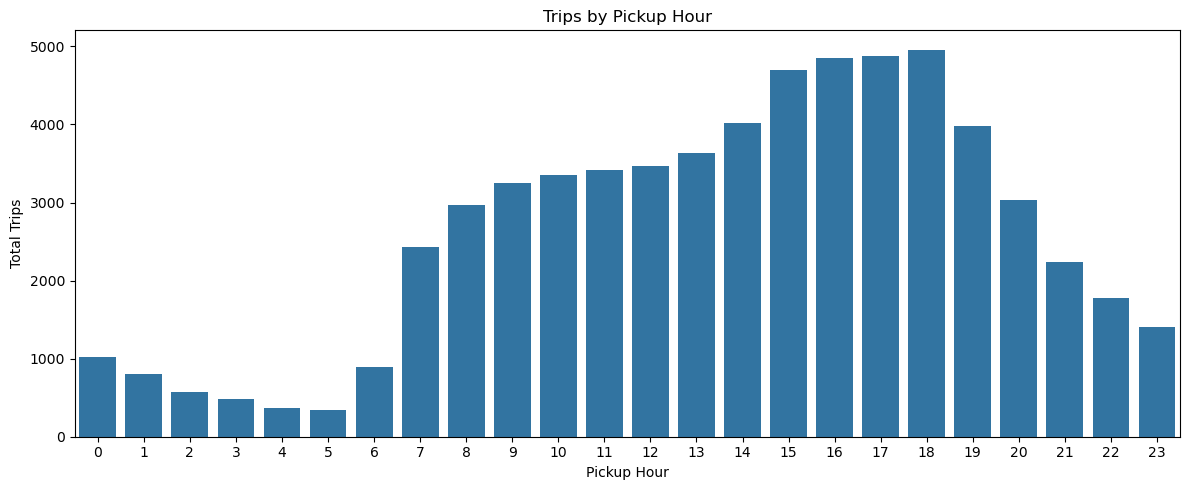

Peak pickup hour: 18:00 dengan 4,958 trips


In [30]:
peak_hour = hourly_demand.loc[hourly_demand['total_trips'].idxmax(), 'pickup_hour']
peak_trips = hourly_demand['total_trips'].max()

plt.figure(figsize=(12, 5))
sns.barplot(data=hourly_demand, x='pickup_hour', y='total_trips')
plt.title('Trips by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Total Trips')
plt.tight_layout()
plt.show()

print(f'Peak pickup hour: {peak_hour}:00 dengan {peak_trips:,.0f} trips')


Demand perjalanan meningkat pada siang hingga sore hari dan mencapai puncaknya pada sore/menjelang malam. Pola ini menunjukkan bahwa operator dapat memprioritaskan ketersediaan armada pada jam dengan demand tertinggi.


## 7.3 Distribusi Metode Pembayaran

Analisis ini digunakan untuk memahami preferensi metode pembayaran pelanggan. Pada dashboard final, visualisasi ini ditampilkan dalam bentuk donut chart.


In [31]:
payment_summary = df_clean.groupby('payment_label').agg(
    total_trips=('payment_label', 'count'),
    avg_fare=('fare_amount', 'mean'),
    avg_tip=('tip_amount', 'mean')
).reset_index()

payment_summary['trip_percentage'] = (
    payment_summary['total_trips'] / payment_summary['total_trips'].sum() * 100
).round(2)

payment_summary = payment_summary.sort_values('total_trips', ascending=False)
payment_summary


,payment_label,total_trips,avg_fare,avg_tip,trip_percentage
1,Credit card,37582,15.30,3.18,59.82
0,Cash,21089,14.66,0.00,33.57
4,Unknown,3952,22.61,3.34,6.29
3,No charge,165,9.77,0.00,0.26
2,Dispute,33,10.28,0.00,0.05


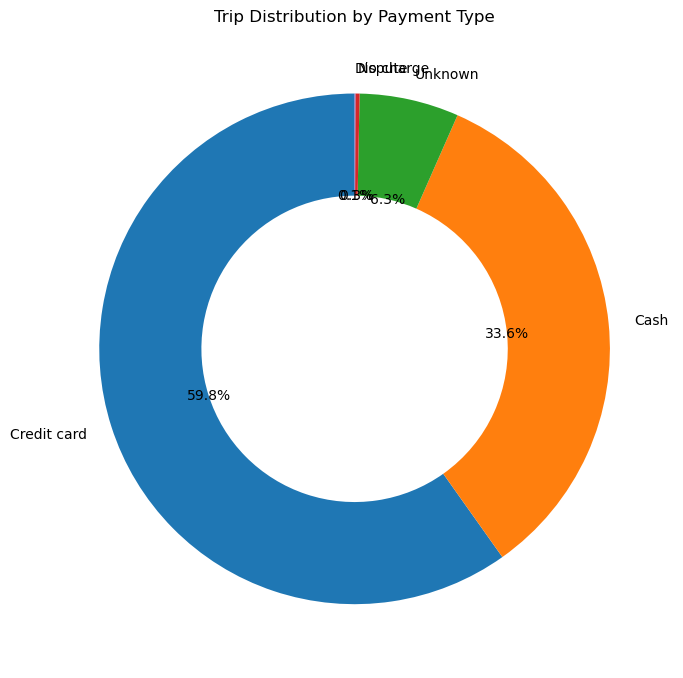

In [32]:
plt.figure(figsize=(7, 7))
plt.pie(
    payment_summary['total_trips'],
    labels=payment_summary['payment_label'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.title('Trip Distribution by Payment Type')
plt.tight_layout()
plt.show()


Credit card menjadi metode pembayaran yang paling dominan, diikuti oleh cash. Hal ini menunjukkan bahwa mayoritas pelanggan menggunakan metode pembayaran non-cash dalam perjalanan taxi.


## 7.4 Distribusi Passenger Group

In [33]:
passenger_summary = df_clean.groupby('passenger_group').agg(
    total_trips=('passenger_group', 'count'),
    avg_fare=('fare_amount', 'mean'),
    avg_tip=('tip_amount', 'mean')
).reset_index()

passenger_summary['trip_percentage'] = (
    passenger_summary['total_trips'] / passenger_summary['total_trips'].sum() * 100
).round(2)

passenger_summary = passenger_summary.sort_values('total_trips', ascending=False)
passenger_summary


,passenger_group,total_trips,avg_fare,avg_tip,trip_percentage
0,1 passenger,49956,14.93,2.01,79.52
1,2 passengers,4702,16.09,2.14,7.48
3,Unknown/0,4231,22.02,3.26,6.74
2,3+ passengers,3932,15.50,2.19,6.26


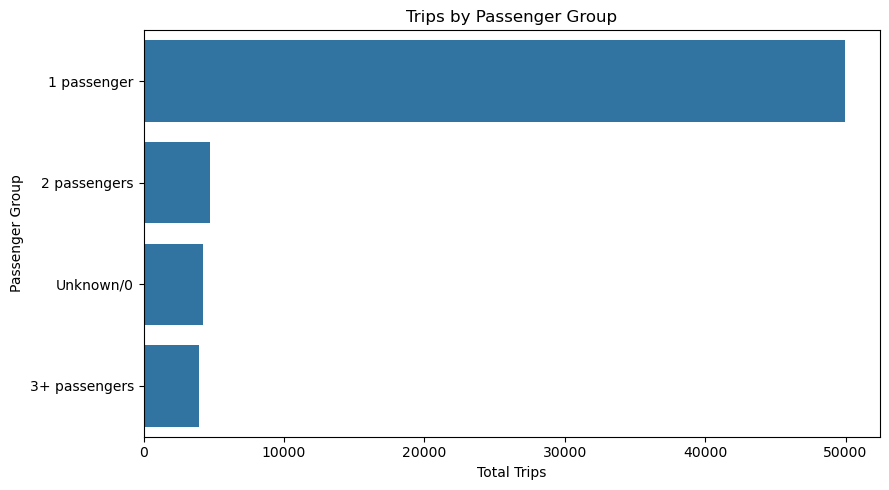

In [34]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=passenger_summary,
    y='passenger_group',
    x='total_trips',
    order=passenger_summary['passenger_group']
)
plt.title('Trips by Passenger Group')
plt.xlabel('Total Trips')
plt.ylabel('Passenger Group')
plt.tight_layout()
plt.show()


Kelompok **1 passenger** mendominasi jumlah perjalanan. Artinya, mayoritas perjalanan taxi pada dataset ini digunakan untuk perjalanan individu, bukan perjalanan berkelompok.


# 8. Statistical Analysis

In [35]:
credit = df_clean.loc[df_clean['payment_label'] == 'Credit card', 'total_without_tip'].dropna()
cash = df_clean.loc[df_clean['payment_label'] == 'Cash', 'total_without_tip'].dropna()

print(f'Jumlah data Credit card: {len(credit):,}')
print(f'Jumlah data Cash: {len(cash):,}')
print(f'Median Credit card total_without_tip: {credit.median():,.2f}')
print(f'Median Cash total_without_tip: {cash.median():,.2f}')


Jumlah data Credit card: 37,582
Jumlah data Cash: 21,089
Median Credit card total_without_tip: 16.35
Median Cash total_without_tip: 14.60


In [36]:
u_stat, p_value = stats.mannwhitneyu(credit, cash, alternative='two-sided')

print(f'Mann-Whitney U statistic: {u_stat:,.2f}')
print(f'p-value: {p_value:.6f}')

alpha = 0.05
if p_value < alpha:
    print('Keputusan: Tolak H0. Terdapat perbedaan signifikan antara Credit card dan Cash.')
else:
    print('Keputusan: Gagal menolak H0. Tidak terdapat perbedaan signifikan antara Credit card dan Cash.')


Mann-Whitney U statistic: 443,764,558.50
p-value: 0.000000
Keputusan: Tolak H0. Terdapat perbedaan signifikan antara Credit card dan Cash.


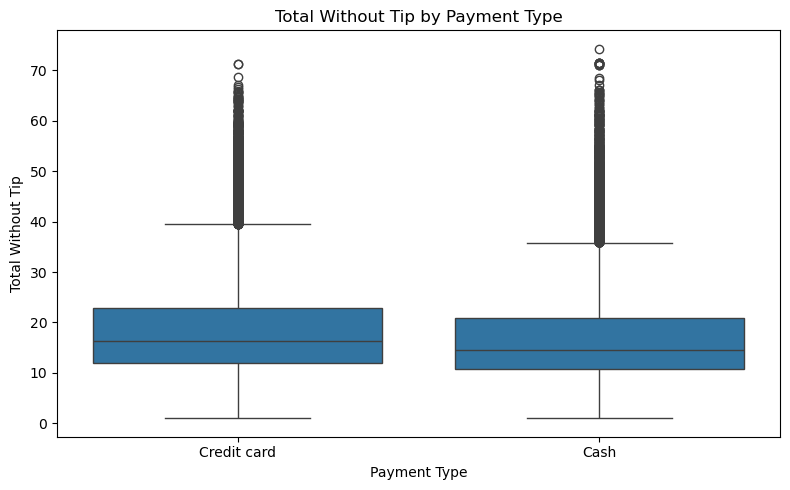

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean[df_clean['payment_label'].isin(['Credit card', 'Cash'])],
    x='payment_label',
    y='total_without_tip'
)
plt.title('Total Without Tip by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Total Without Tip')
plt.tight_layout()
plt.show()


# 9. Kesimpulan

Berdasarkan hasil analisis dan dashboard Looker Studio:

1. **Pola waktu:** Jumlah perjalanan cenderung meningkat pada siang hingga sore hari, dengan aktivitas tertinggi terjadi pada rentang sore/menjelang malam.
2. **Payment type:** Credit card merupakan metode pembayaran yang paling banyak digunakan, diikuti oleh cash.
3. **Passenger group:** Mayoritas perjalanan dilakukan oleh **1 passenger**, sehingga perjalanan individu menjadi pola perjalanan yang paling dominan.
4. **KPI perjalanan:** Dashboard menampilkan ringkasan performa utama berupa total trip, average fare, average fare per mile, dan average tip untuk memberikan gambaran cepat terhadap performa dataset.


# 10. Rekomendasi Bisnis

Rekomendasi yang dapat diberikan berdasarkan analisis:

1. **Optimasi armada pada jam sibuk:** Operator dapat meningkatkan ketersediaan armada pada jam dengan demand tertinggi, terutama pada sore hingga menjelang malam.
2. **Monitoring demand per jam:** Dashboard perlu digunakan untuk memantau pola demand secara rutin agar strategi operasional dapat disesuaikan dengan perubahan pola pelanggan.
3. **Dukungan pembayaran non-cash:** Karena Credit card menjadi metode pembayaran dominan, operator perlu memastikan sistem pembayaran non-cash berjalan stabil dan mudah digunakan.
4. **Fokus pada perjalanan individu:** Karena mayoritas trip dilakukan oleh satu penumpang, strategi layanan dapat difokuskan pada kebutuhan individual travel, seperti ketersediaan armada cepat dan efisiensi waktu tunggu.
5. **Evaluasi KPI berkala:** Total trip, average fare, average fare per mile, dan average tip perlu dipantau secara berkala untuk melihat perubahan performa operasional.


# 11. Export Cleaned Data

In [38]:
output_path = 'nyc_tlc_cleaned_for_dashboard.csv'
df_clean.to_csv(output_path, index=False)
print(f'Cleaned data exported to: {output_path}')


Cleaned data exported to: nyc_tlc_cleaned_for_dashboard.csv
